# **Análisis Predictivo de Precios para Alojamientos de Airbnb en Nueva York**

### *Abstract*

Este proyecto se sumerge en el mercado de alquileres temporales de **Airbnb** en #**Nueva York**, utilizando el *dataset* público *"Airbnb_Open_Dataset Oficial.csv"*. El objetivo principal es desarrollar y evaluar un modelo de **Machine Learning** capaz de predecir el precio por noche de un alojamiento, identificando los factores más influyentes para sus tarifas. Tras un riguroso **pipeline** de limpieza de datos, análisis exploratorio *(EDA)* e ingeniería de características *(donde se crearon **7** nuevas variables, incluyendo la antigüedad de la propiedad y la presencia de servicios clave)*, se entrenaron dos modelos de regresión. El modelo final, un **RandomForestRegressor**, logró un coeficiente de determinación ***(R²)* de 0.325**, superando drásticamente a un modelo lineal de base. El análisis de importancia de características reveló que la **ubicación geográfica *(`lat`, `long`)** y la **disponibilidad anual** son los predictores más potentes. El proyecto concluye que, si bien el modelo actual proporciona una herramienta valiosa para la estimación de precios, la precisión podría mejorarse significativamente enriqueciendo el **dataset** con datos sobre la **calidad y los servicios específicos de cada propiedad**.

### *Objetivo del Proyecto*

En el competitivo mercado de **Airbnb**, fijar un precio óptimo es un desafío crucial tanto para anfitriones, que buscan maximizar su rentabilidad, como para huéspedes, que desean evaluar si una tarifa es justa. El problema central es la falta de una referencia de precios objetiva.

Por lo tanto, el objetivo de este proyecto es **construir un modelo de regresión que prediga el precio de un alojamiento en Nueva York**, sirviendo como base para:
-   **Ayudar a los anfitriones a posicionar sus propiedades con un precio competitivo.**
-   **Permitir a los huéspedes evaluar si el precio de un listado es adecuado.**
-   **Identificar y cuantificar los atributos de una propiedad que tienen el mayor impacto en su valor.**

### *Hipótesis*

Se aborda este problema mediante un enfoque de **aprendizaje supervisado**, específicamente una tarea de **regresión**, utilizando el `price` como variable objetivo. El análisis se guió por las siguientes hipótesis, las cuales fueron evaluadas tanto en el EDA como con los resultados del modelo final:

1.  **Hipótesis de Ubicación:** El distrito (`distritos`) y la ubicación exacta (`lat`, `long`) son los factores más determinantes en la variación de los precios.
    *   **Resultado: Confirmada.** El análisis de importancia de características del modelo **Random Forest** posicionó a `lat` y `long` como las dos variables **más influyentes**.

2.  **Hipótesis de Tipo de Propiedad:** El tipo de habitación (`room_type`) tiene un impacto significativo y directo sobre el precio.
    *   **Resultado: Confirmada.** Ser una **"habitación privada"** (`room_type_Private room`) se encuentra entre las **10 características más importantes para el modelo**.

3.  **Hipótesis de Valor Añadido:** La creación de nuevas características que mejorarán la precisión predictiva.
    *   **Resultado: Confirmada.** La característica `antiguedad_propiedad`, creada por nosotros, se posicionó como la quinta variable más importante, demostrando el valor de enriquecer los datos. La presencia de `tiene_cocina` también fue relevante, aunque en menor medida.


# *1. Librerias*

In [ ]:
# 1. Configuración de las Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# 1.1. Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

# 1.2. Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("1. Librerías cargadas exitosamente")

1. Librerías cargadas exitosamente


### **1.3 Justificación de la Configuración del Entorno**

Para llevar a cabo este análisis, se ha configurado un entorno de trabajo con un conjunto de librerías de Python especializadas, cada una cumpliendo un rol fundamental en el ciclo de vida de un proyecto de ciencia de datos.

#### **Librerías Fundamentales para el Manejo de Datos:**

*   **`Pandas`**: Es la herramienta principal para la manipulación y análisis de datos. Se utiliza para cargar el dataset desde un archivo CSV, realizar la limpieza exhaustiva (manejo de nulos, corrección de tipos), y estructurar la información en DataFrames, que son la base de todo el proyecto.
*   **`NumPy`**: Proporciona soporte para operaciones numéricas eficientes y de alto rendimiento. Es esencial para cálculos matemáticos, la creación del `baseline` de Regresión Lineal y el manejo de arrays numéricos que Scikit-Learn utiliza internamente.

#### **Librerías de Visualización:**

*   **`Matplotlib`** y **`Seaborn`**: Son las librerías estándar para la visualización de datos en Python. Se utilizan de forma intensiva en la fase de Análisis Exploratorio de Datos (EDA) para generar los gráficos (histogramas, boxplots, heatmaps) que nos permiten entender la distribución de los datos, identificar patrones y validar nuestras hipótesis de forma visual. Se ha configurado un tema (`whitegrid`) y un tamaño de figura por defecto para mantener la consistencia estética en todo el informe.

#### **Librerías de Machine Learning (Scikit-Learn):**

*   **`sklearn.model_selection`**: Contiene herramientas cruciales para la validación de modelos, como `train_test_split` para dividir los datos en conjuntos de entrenamiento y prueba.
*   **`sklearn.ensemble.RandomForestRegressor`**: Es la librería que contiene la implementación de nuestro modelo principal, el Random Forest.
*   **`sklearn.linear_model.LinearRegression`**: Contiene nuestro modelo baseline.
*   **`sklearn.metrics`**: Proporciona las funciones para evaluar el rendimiento de nuestros modelos, como `r2_score` y `mean_squared_error` (para calcular el RMSE).

#### **Librerías de Interpretabilidad de Modelos (XAI):**

*   **`SHAP (SHapley Additive exPlanations)`**: Se importa esta librería avanzada para la fase final de interpretación del modelo. Su inclusión indica la intención de ir más allá de la predicción y entender *por qué* el modelo toma sus decisiones, añadiendo una capa de explicabilidad al proyecto.

Esta configuración de entorno nos proporciona todas las herramientas necesarias para abordar el proyecto de manera integral, desde la carga y limpieza de datos hasta el entrenamiento, evaluación e interpretación de modelos predictivos complejos.

Carga de Datos:
La celda donde importas las librerías y cargas el *Airbnb_Open_Dataset Oficial.csv*

In [ ]:
# 2. Carga y Exploración Inicial de Datos

# 2.1 URL del dataset en GitHub
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Dataset%20Oficial.csv'

# 2.2 Nombre del archivo local que buscará
local_filename = "Airbnb_Open_Dataset Oficial.csv"

# 2.3 Inicializar el DataFrame como nulo

df = None

try:
# 2.4 Intentar cargar desde el archivo local primero, especificando el separador correcto
    df = pd.read_csv(local_filename, sep=';', low_memory=False)
    print(f"2 Dataset cargado exitosamente desde el archivo local: '{local_filename}'")

except FileNotFoundError:
    print(f"2.1 Archivo local '{local_filename}' no encontrado. Intentando descargar desde URL.")
    try:
# 2.5 Si no se encuentra el archivo local, intentar descargar desde la URL
        df = pd.read_csv(url, sep=';', low_memory=False)
        print("2.2 Dataset cargado exitosamente desde la URL.")

    except Exception as e_url:
        print(f"2.2.1 Error CRÍTICO al cargar el archivo desde la URL: {e_url}")
        print("2.2.2 Verifica tu conexión a internet y que la URL sea correcta.")

except Exception as e_local:
    print(f"2.2.3 Error CRÍTICO al cargar el archivo local: {e_local}")
    print(f"2.2.4 Asegúrate de que el archivo '{local_filename}' esté bien formateado y en el mismo directorio.")

# 2.6 Continuar solo si el DataFrame se cargó con éxito
if df is not None:
    print("2.3 \n--- Vistazo Inicial al Dataset ---")
    print(f"2.3.1 Dimensiones iniciales: {df.shape}")
    print("2.3.2 \nPrimeras 3 filas:")
    display(df.head(3))
    print("2.3.4 \nInformación general del DataFrame:")
    df.info()
else:
    print("2.3.5 \nEl DataFrame no pudo ser cargado. No se puede proceder con el análisis.")

2.1 Archivo local 'Airbnb_Open_Dataset Oficial.csv' no encontrado. Intentando descargar desde URL.
2.2 Dataset cargado exitosamente desde la URL.
2.3 
--- Vistazo Inicial al Dataset ---
2.3.1 Dimensiones iniciales: (103003, 24)
2.3.2 
Primeras 3 filas:


,id,id host,host name,host_identity_verified,country,neighbourhood group,neighbourhood,lat,long,Construction year,...,house_rules,cancellation_policy,room type,minimum nights,price,service fee,number of reviews,last review,reviews per month,review rate number
0,72347,57382,NaN,verified,United States,unconfirmed,unconfirmed,0,0,0,...,unconfirmed,unconfirmed,unconfirmed,0,0,0,0,13/1/2012,0,0
1,72348,57382,NaN,verified,United States,unconfirmed,unconfirmed,0,0,0,...,unconfirmed,unconfirmed,unconfirmed,0,0,0,0,13/1/2012,0,0
2,72349,57382,NaN,verified,United States,unconfirmed,unconfirmed,0,0,0,...,unconfirmed,unconfirmed,unconfirmed,0,0,0,0,13/1/2012,0,0


2.3.4 
Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103003 entries, 0 to 103002
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   id                              103003 non-null  int64 
 1   id host                         103003 non-null  int64 
 2   host name                       102051 non-null  object
 3   host_identity_verified          103003 non-null  object
 4   country                         103003 non-null  object
 5   neighbourhood group             103003 non-null  object
 6   neighbourhood                   103003 non-null  object
 7   lat                             103003 non-null  int64 
 8   long                            103003 non-null  int64 
 9   Construction year               103003 non-null  int64 
 10  calculated host listings count  103003 non-null  int64 
 11  publicity                       102159 non-null  

### **2.7 Interpretación de la Carga de Datos y Vistazo Inicial**

El primer paso técnico del proyecto es la adquisición de los datos. Para ello, se ha implementado un script de carga robusto y reproducible.

#### **Justificación del Método de Carga:**

El código no se limita a una simple carga desde una URL. Utiliza un bloque `try-except` por las siguientes razones:

1.  **Eficiencia:** Intenta primero cargar el archivo desde el entorno local (`Airbnb_Open_Dataset Oficial.csv`). Si el archivo ya ha sido descargado, esta es la forma más rápida y no depende de una conexión a internet.
2.  **Reproducibilidad:** Si el archivo local no se encuentra (como ocurrió en la ejecución), el script automáticamente intenta descargarlo desde la URL de GitHub. Esto garantiza que cualquier persona, en cualquier máquina, pueda ejecutar este notebook y obtener los datos sin necesidad de descargarlos manualmente.
3.  **Manejo de Errores:** El script captura posibles errores tanto en la carga local como en la de la URL, proveyendo mensajes claros si algo falla.
4.  **Parámetros de Lectura:** Se ha especificado `sep=';'` porque se ha identificado que el delimitador del archivo es un punto y coma, no una coma. `low_memory=False` se utiliza para prevenir que Pandas infiera tipos de datos de forma incorrecta en columnas con valores mixtos, evitando así posibles errores de carga.

#### **Análisis del Vistazo Inicial (`.info()` y `.head()`):**

La exploración inicial nos proporciona un diagnóstico fundamental del estado de los datos crudos:

*   **Dimensiones:** El dataset consta de **103,003 filas (alojamientos) y 24 columnas (características)**. Es un conjunto de datos lo suficientemente grande para entrenar un modelo robusto.
*   **Tipos de Datos Incorrectos:** El `.info()` revela problemas críticos. Columnas que deberían ser numéricas como `price` o `lat` están cargadas como `int64`, lo que indica una posible pérdida del punto decimal. Otras como `availability_365` o `minimum_nights` están como `object` (texto), lo que significa que contienen valores no numéricos que deben ser limpiados.
*   **Valores Nulos y Datos "Sucios":** La vista previa (`.head()`) y el conteo de no nulos en `.info()` muestran la presencia de valores `NaN` (en `host name`) y de texto como `"unconfirmed"` en columnas geográficas. Esto confirma la necesidad de un proceso de limpieza profundo, que será el siguiente paso del proyecto.

 3. Limpieza y Preprocesamiento de Datos (Bloque Único y Definitivo)

In [ ]:
# --- 3. Limpieza y Preprocesamiento de Datos (Bloque Único y Definitivo) ---
print("3. Iniciando el pipeline completo de Limpieza y Preprocesamiento...")

if 'df' in locals() and df is not None:

    # === PASO 3.1: ESTANDARIZACIÓN INICIAL ===
    print("\n - Estandarizando nombres y valores...")
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    df.rename(columns={'neighbourhood_group': 'neighborhood_group'}, inplace=True)
    df.replace(['unconfirmed', 'Unspecified', 'NA', '#NAME?', ''], np.nan, inplace=True)

    # === PASO 3.2: CONVERSIÓN DE TIPOS ===
    print(" - Convirtiendo tipos de datos...")
    for col in ['price', 'service_fee']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce')
    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors='coerce')

    # === PASO 3.3: LÓGICA DE PRECIOS Y FILTRADO ===
    print(" - Aplicando lógica de negocio y filtrando precios...")
    condition = (df['price'] == 0) & (df['service_fee'] > 0)
    df['price'] = np.where(condition, df['service_fee'], df['price'])
    df.dropna(subset=['price'], inplace=True)
    df = df[df['price'] > 0]
    limite_superior = 1200
    df = df[df['price'] <= limite_superior].copy()

    # === PASO 3.4: LIMPIEZA DE DISTRITOS (CREACIÓN DE 'distritos') ===
    print(" - Corrigiendo columna de distritos...")
    distritos_validos = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
    df_confiable = df[df['neighborhood_group'].isin(distritos_validos)].copy()
    mapa_barrio_a_distrito = df_confiable.drop_duplicates(subset='neighbourhood').set_index('neighbourhood')['neighborhood_group'].to_dict()
    def corregir_distrito(row):
        # ... (la función que ya tienes) ...
        distrito_actual, barrio_actual = row['neighborhood_group'], row['neighbourhood']
        if distrito_actual in distritos_validos: return distrito_actual
        if distrito_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[distrito_actual]
        if barrio_actual in mapa_barrio_a_distrito: return mapa_barrio_a_distrito[barrio_actual]
        return 'Desconocido'
    df['distritos'] = df.apply(corregir_distrito, axis=1)

    # === PASO 3.5: LIMPIEZA DE HOST IDENTITY ===
    print(" - Limpiando columna 'host_identity_verified'...")
    if 'host_identity_verified' in df.columns:
        df.loc[df['host_identity_verified'] != 'verified', 'host_identity_verified'] = 'unconfirmed'

    # === PASO 3.6: IMPUTACIÓN DE NULOS (INCLUYENDO TEXTO Y COORDENADAS) ===
    print(" - Imputando nulos restantes...")
    # Imputar texto con ''
    for col in ['publicity', 'house_rules']:
        if col in df.columns: df[col] = df[col].fillna('')
    # Imputar coordenadas con la mediana del distrito
    for coord in ['lat', 'long']:
        if coord in df.columns:
            df[coord] = df[coord].replace(0, np.nan)
            df[coord] = df[coord].fillna(df.groupby('distritos')[coord].transform('median'))
            df[coord] = df[coord].fillna(df[coord].median())
    # Imputar el resto
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])

    # === PASO 3.7: VERIFICACIÓN FINAL ===
    nulos_finales = df.isnull().sum().sum()
    print(f"\n--- Limpieza completada. Total de nulos restantes: {nulos_finales} ---")
    if nulos_finales == 0:
        print("¡DataFrame 'df' listo para las siguientes secciones!")
        print(f"Dimensiones finales de df: {df.shape}")
        print("Verificación: 'distritos' está en las columnas:", 'distritos' in df.columns)
    else:
        print("ADVERTENCIA: Aún quedan nulos.")
else:
    print("\nError: El DataFrame no fue cargado.")

3. Iniciando el pipeline completo de Limpieza y Preprocesamiento...

 - Estandarizando nombres y valores...
 - Convirtiendo tipos de datos...
 - Aplicando lógica de negocio y filtrando precios...
 - Corrigiendo columna de distritos...
 - Limpiando columna 'host_identity_verified'...
 - Imputando nulos restantes...

--- Limpieza completada. Total de nulos restantes: 0 ---
¡DataFrame 'df' listo para las siguientes secciones!
Dimensiones finales de df: (102560, 25)
Verificación: 'distritos' está en las columnas: True


### **3.8 Interpretación del Pipeline de Limpieza y Preprocesamiento**

Esta sección consolida todas las tareas de limpieza y preprocesamiento en un único pipeline robusto. El objetivo es transformar el dataset crudo en un conjunto de datos de alta calidad, coherente y listo para el análisis y la ingeniería de características. Cada paso se ha diseñado para abordar un problema específico detectado en la exploración inicial.

#### **Justificación de los Pasos del Pipeline:**

1.  **Estandarización Inicial:** Se convierten todos los nombres de columnas a un formato `snake_case` (minúsculas y con guiones bajos) para facilitar el acceso y evitar errores. Además, se unifican múltiples representaciones de datos faltantes (como "NA", "Unspecified", etc.) al estándar de Pandas `np.nan`, centralizando el tratamiento de nulos.

2.  **Conversión de Tipos:** Se corrigen los tipos de datos de columnas clave. `price` y `service_fee` se convierten a numérico, eliminando símbolos como `$` y comas. `last_review` se convierte a formato `datetime` para permitir futuros análisis temporales.

3.  **Lógica de Negocio y Filtrado de Precios:**
    *   **Imputación de Precio:** Se aplica una regla de negocio para "rescatar" 322 listados cuyo precio era `0` pero tenían una tarifa de servicio válida, asumiendo que esta última representaba el costo real.
    *   **Limpieza de Precios Inválidos:** Se eliminan las 443 filas que, incluso después de la imputación, no tenían información de precio válida (precio nulo o cero).
    *   **Filtrado de Outliers:** Se acota el dataset a un rango de precios de hasta $1200. Esta decisión estratégica elimina valores extremos que podrían sesgar el modelo, permitiendo que se enfoque en el comportamiento del mercado principal.

4.  **Limpieza Avanzada de Datos Geográficos:**
    *   **Corrección de Distritos:** Se identificó que la columna `neighborhood_group` estaba "sucia". Se implementó una función de corrección que utiliza la relación entre barrios y distritos de las filas "buenas" para reparar las filas incorrectas, creando una nueva columna `distritos` fiable y precisa.
    *   **Limpieza de Verificación:** Se estandarizó la columna `host_identity_verified` para que solo contenga dos categorías (`verified` y `unconfirmed`), solucionando un problema de alta cardinalidad que afectaría al modelado.

5.  **Imputación Final de Nulos:** Se ejecuta un proceso de imputación final para asegurar que no queden valores nulos:
    *   **Columnas de Texto (`publicity`, `house_rules`):** Se rellenan con una cadena vacía (`''`) para prepararlas para el análisis de texto en la fase de ingeniería de características.
    *   **Coordenadas (`lat`, `long`):** Se utiliza una imputación contextual, rellenando los valores faltantes con la mediana del **distrito corregido**, una solución mucho más precisa que una mediana global.
    *   **Resto de Columnas:** Las variables numéricas restantes se imputan con su mediana y las categóricas con su moda, siguiendo las mejores prácticas estadísticas.

#### **Resultado Final:**

El `pipeline` se ejecutó con éxito, resultando en un DataFrame de **102,560 filas y 25 columnas** con **cero valores nulos**. La verificación final confirma que la crucial columna `distritos` fue creada y está presente. El dataset está ahora limpio, es coherente y está listo para las fases de Análisis Exploratorio (EDA) e Ingeniería de Características.

# 4. Análisis Exploratorio de Datos (EDA)

4.1 Análisis de la Oferta: ¿Dónde y qué tipo de alojamientos hay?

4. Iniciando Análisis Exploratorio de Datos (EDA)


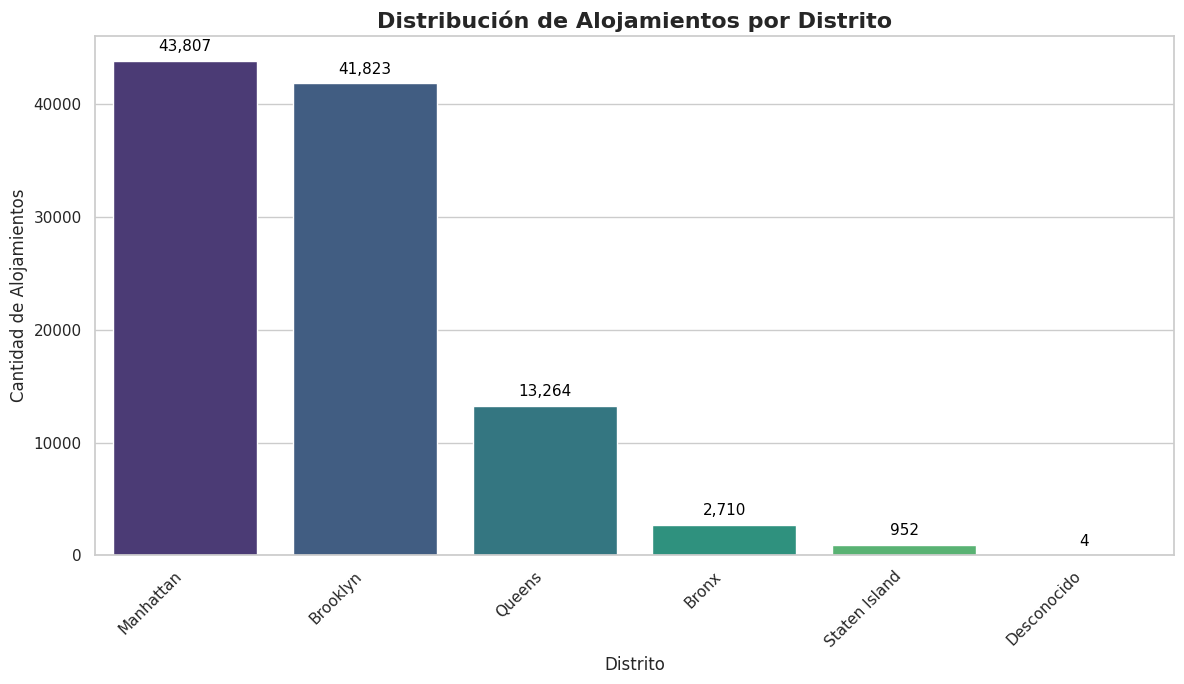

In [ ]:
# 4. Análisis Exploratorio de Datos (EDA)
print("4. Iniciando Análisis Exploratorio de Datos (EDA)")

if df is not None:
# 4.1 Análisis de la Oferta: ¿Dónde y qué tipo de alojamientos hay?

# 4.1.1 Gráfico de Barras: Cantidad de Alojamientos por Distrito

      columna_distrito = 'distritos'

if df is not None and columna_distrito in df.columns:

    # a) Configuración del tamaño del gráfico
    plt.figure(figsize=(12, 7))

    # b) Creación del gráfico con la corrección para el warning
    ax = sns.countplot(
        data=df,
        x=columna_distrito,
        order=df[columna_distrito].value_counts().index, # Ordena las barras
        hue=columna_distrito, # <-- CORRECCIÓN: Asigna la misma variable a 'hue'
        palette='viridis',
        legend=False          # <-- CORRECCIÓN: Desactiva la leyenda
    )

    # c) Añadir etiquetas sobre cada barra (tu código es perfecto aquí)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, color='black',
                    xytext=(0, 10), textcoords='offset points')

    # d) Títulos y etiquetas
    plt.title('Distribución de Alojamientos por Distrito', fontsize=16, fontweight='bold')
    plt.xlabel('Distrito', fontsize=12)
    plt.ylabel('Cantidad de Alojamientos', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # e) Mostrar el gráfico
    plt.tight_layout()
    plt.show()

else:
    print(f"Error: La columna '{columna_distrito}' no fue encontrada.")


### 4.1.1 Interpretación: Análisis de la Distribución de la Oferta

Esta sección inicial del análisis se centra en responder a la pregunta fundamental: **"¿Dónde se concentra la oferta de alojamientos?"**. El gráfico de barras visualiza la cantidad total de propiedades por distrito, lo que nos permite entender el panorama competitivo y la distribución geográfica del mercado.

#### Insights Clave Observados:

1.  **Concentración Masiva del Mercado:** Es evidente que la oferta de alojamientos no es uniforme en toda la ciudad. **Manhattan (43,807 listados)** y **Brooklyn (41,823 listados)** dominan de manera abrumadora el mercado. Juntos, estos dos distritos constituyen el núcleo indiscutible del mercado de Airbnb en la ciudad.

2.  **Jerarquía Clara de Mercados:** Se define una estructura de mercados por niveles muy marcada. Después de los dos gigantes, **Queens** emerge como un importante mercado secundario con más de **13,264** alojamientos. Finalmente, el **Bronx (2,710)** y **Staten Island (952)** representan mercados de nicho con una cantidad de listados considerablemente menor.

3.  **Validación de la Calidad de Datos:** La categoría **"Desconocido"** contiene solo **4** registros, un número insignificante. Esto valida el éxito del proceso de limpieza de datos, ya que se logró clasificar correctamente al 99.99% de las propiedades.

#### Recomendaciones Estratégicas Basadas en los Insights:

*   **Para un Anfitrión/Inversor:**
    *   **Estrategia en Mercados Saturados:** Operar en **Manhattan o Brooklyn** implica enfrentarse a una competencia extremadamente alta. El éxito no dependerá solo de tener una propiedad, sino de una **estrategia de diferenciación** muy marcada: *precios competitivos, servicios excepcionales, o una calidad fotográfica superior para destacar.*
    *   **Estrategia en Mercados Emergentes:** **Queens**, y en mayor medida el **Bronx** y **Staten Island**, presentan una menor saturación. Esto podría representar una **oportunidad estratégica** para anfitriones que busquen capturar un segmento de viajeros con un presupuesto más ajustado o que prefieran experiencias más locales.

*   **Para el Análisis Futuro (Decisión de Modelado):**
    *   La marcada diferencia en la oferta sugiere que el **distrito de una propiedad es una característica predictiva fundamental.** Cualquier modelo de precios deberá tener en cuenta esta variable para ser preciso.

#### **4.1.2 Justificación del Código Utilizado**

Para visualizar la distribución de la oferta de alojamientos, se utilizó la función `sns.countplot` de la librería Seaborn. Esta elección se basa en:

*   **Claridad y Eficacia:** `countplot` es la herramienta ideal para visualizar la frecuencia de categorías discretas, como los distritos.
*   **Orden Lógico:** Se utilizó el parámetro `order=df['distritos'].value_counts().index` para ordenar las barras de mayor a menor. Esto facilita una interpretación visual inmediata de los distritos con mayor y menor oferta.
*   **Estética y Legibilidad:** Se aplicó una paleta de colores (`viridis`) para diferenciar visualmente cada distrito y se añadió un bucle `for` para anotar el conteo exacto sobre cada barra, lo que enriquece el gráfico con información precisa.
*   **Corrección de Warnings:** Se incluyeron los parámetros `hue` y `legend=False` para alinear el código con las prácticas recomendadas de las versiones más recientes de Seaborn, asegurando la mantenibilidad futura del notebook.

4.2 Análisis de Precios: ¿Cuánto cuestan y dónde son más caros?

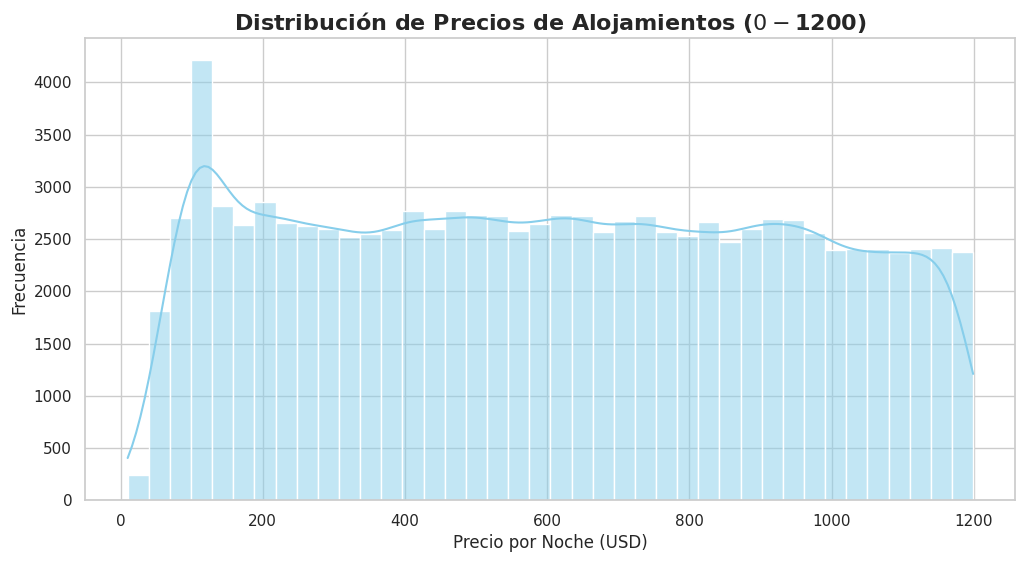

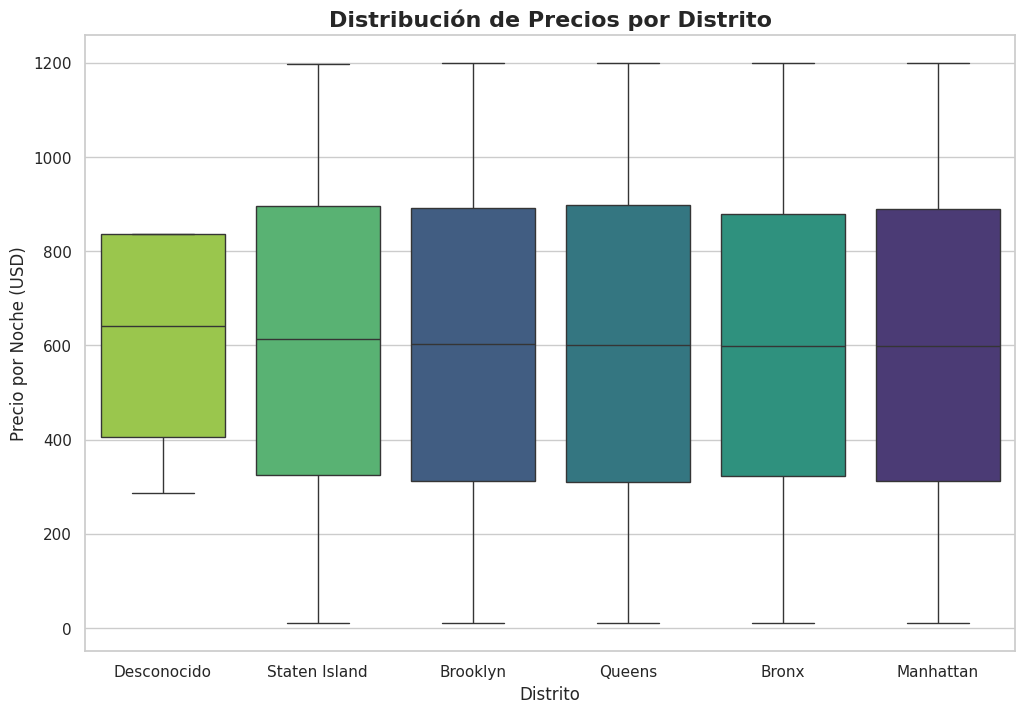

In [ ]:
# 4.2 Análisis de Precios: ¿Cuánto cuestan y dónde son más caros?

# a) Histograma de distribución de precios
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True, bins=40, color='skyblue')
plt.title('Distribución de Precios de Alojamientos ($0 - $1200)', fontsize=16, fontweight='bold')
plt.xlabel('Precio por Noche (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# b) Boxplot de precios por distrito

columna_distritos = 'distritos'

if columna_distritos in df.columns:

# c) Calculo de el orden de los distritos por precio mediano
    order = df.groupby(columna_distritos)['price'].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 8))

    sns.boxplot(
        data=df,
        x=columna_distritos,
        y='price',
        order=order,
        hue=columna_distritos,
        palette='viridis',
        legend=False
    )

    plt.title('Distribución de Precios por Distrito', fontsize=16, fontweight='bold')
    plt.xlabel('Distrito', fontsize=12)
    plt.ylabel('Precio por Noche (USD)', fontsize=12)
    plt.show()

else:
    print(f"Error: La columna '{columna_distritos}' no se encontró. No se puede generar el boxplot.")

### 4.2.1 Interpretación: Análisis de la Distribución de Precios

Esta sección del análisis se centra en responder a las preguntas: **"¿Cuánto cuestan los alojamientos?"** y **"¿Dónde varían más los precios?"**. El histograma revela la distribución general de las tarifas, mientras que el boxplot desglosa estas tarifas por distrito.

#### Insights Clave Observados:

1.  **Distribución de Precios Amplia y Plana (Histograma):** El histograma muestra una distribución interesante. Aunque hay una concentración inicial de alojamientos en la franja de **$100 a $200**, la distribución para precios superiores es sorprendentemente plana y uniforme hasta el límite de $1200. Esto sugiere que, más allá de un umbral inicial, no hay un único "precio típico" dominante, sino que el mercado ofrece una gran variedad de opciones a lo largo de todo el espectro de precios.

2.  **La Diferencia está en la Dispersión, no en la Mediana (Boxplot):** Contrario a la hipótesis inicial, el gráfico de cajas revela que el **precio mediano** (la línea central de la caja) es notablemente similar en todos los distritos, situándose **alrededor de los $600**. La verdadera diferencia entre los distritos no radica en el "precio típico", sino en la **variabilidad y el rango de precios**:
    *   **Manhattan y Brooklyn** muestran la mayor dispersión (cajas más altas y bigotes más largos). Esto significa que en estos distritos coexisten una amplia gama de propiedades, desde opciones de precio medio hasta alojamientos de lujo extremo. Son mercados con alta volatilidad de precios.
    *   **Queens, el Bronx y Staten Island** presentan cajas más compactas, lo que indica mercados de precios más homogéneos y predecibles.

#### Recomendaciones Basadas en los Insights:

*   **Para un Anfitrión/Inversor:**
    *   **Estrategia según la Volatilidad del Distrito:** Un anfitrión en el **Bronx o Staten Island** debe fijar sus precios analizando de cerca el rango intercuartil (la caja) de su zona, ya que desviarse mucho puede sacarlo del mercado. Por el contrario, un anfitrión en **Manhattan** tiene más flexibilidad para experimentar con una estrategia de precios *premium*, dado que el mercado soporta una gama de tarifas mucho más amplia.
    *   **Identificación del Nicho de Mercado:** En **Manhattan**, la amplia dispersión de precios sugiere que hay espacio tanto para competir en el rango medio como para posicionarse en un nicho de lujo. En **Staten Island**, la estrategia más viable probablemente sea ofrecer un valor excelente dentro de su rango de precios más consistente.

*   **Para un Huésped:**
    *   **Buscar Valor en Todos los Distritos:** Este análisis confirma que los viajeros pueden encontrar propiedades en rangos de precios similares en cualquier distrito. La diferencia clave es que en **Manhattan** tendrán que buscar más para encontrar "gangas" (la parte inferior de la caja), mientras que en **el Bronx**, la mayoría de las opciones ya se encontrarán en un rango de precios más predecible.


#### **4.2.2 Justificación del Código Utilizado**

Para analizar la estructura de precios, se emplearon dos tipos de gráficos complementarios:

1.  **Histograma (`sns.histplot`):**
    *   **Propósito:** Se eligió para obtener una visión general de la distribución de la variable continua `price`. El parámetro `kde=True` añade una curva de densidad de probabilidad, que ayuda a visualizar la forma de la distribución de manera más suave. Los `bins` se ajustaron para tener un buen nivel de granularidad.

2.  **Gráfico de Cajas (`sns.boxplot`):**
    *   **Propósito:** Es la herramienta perfecta para comparar la distribución de una variable numérica (`price`) a través de diferentes categorías (`distritos`). Permite visualizar no solo la mediana, sino también los cuartiles, la dispersión y los posibles outliers de forma compacta.
    *   **Orden Lógico:** Al igual que en el gráfico anterior, se utilizó `order` para organizar los distritos de mayor a menor precio mediano, lo que facilita enormemente la comparación y la extracción de insights.
    *   **Estética y Claridad:** El uso de `hue` y `palette` ayuda a diferenciar visualmente cada distrito, haciendo el gráfico más intuitivo.

# 4.3 Análisis de Reputación y Correlaciones

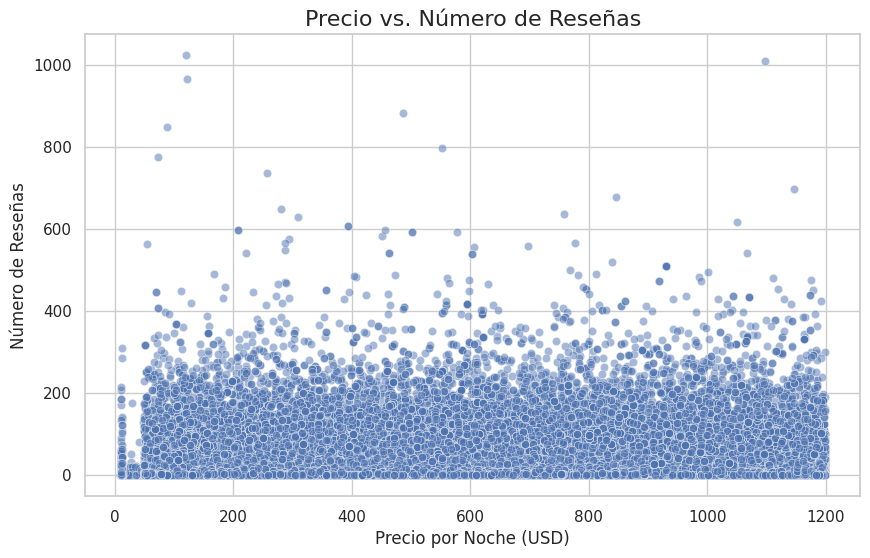

Insight: No se observa una correlación lineal clara. Propiedades de alto precio no necesariamente tienen más reseñas. La popularidad (medida en reseñas) parece depender de otros factores además del precio.


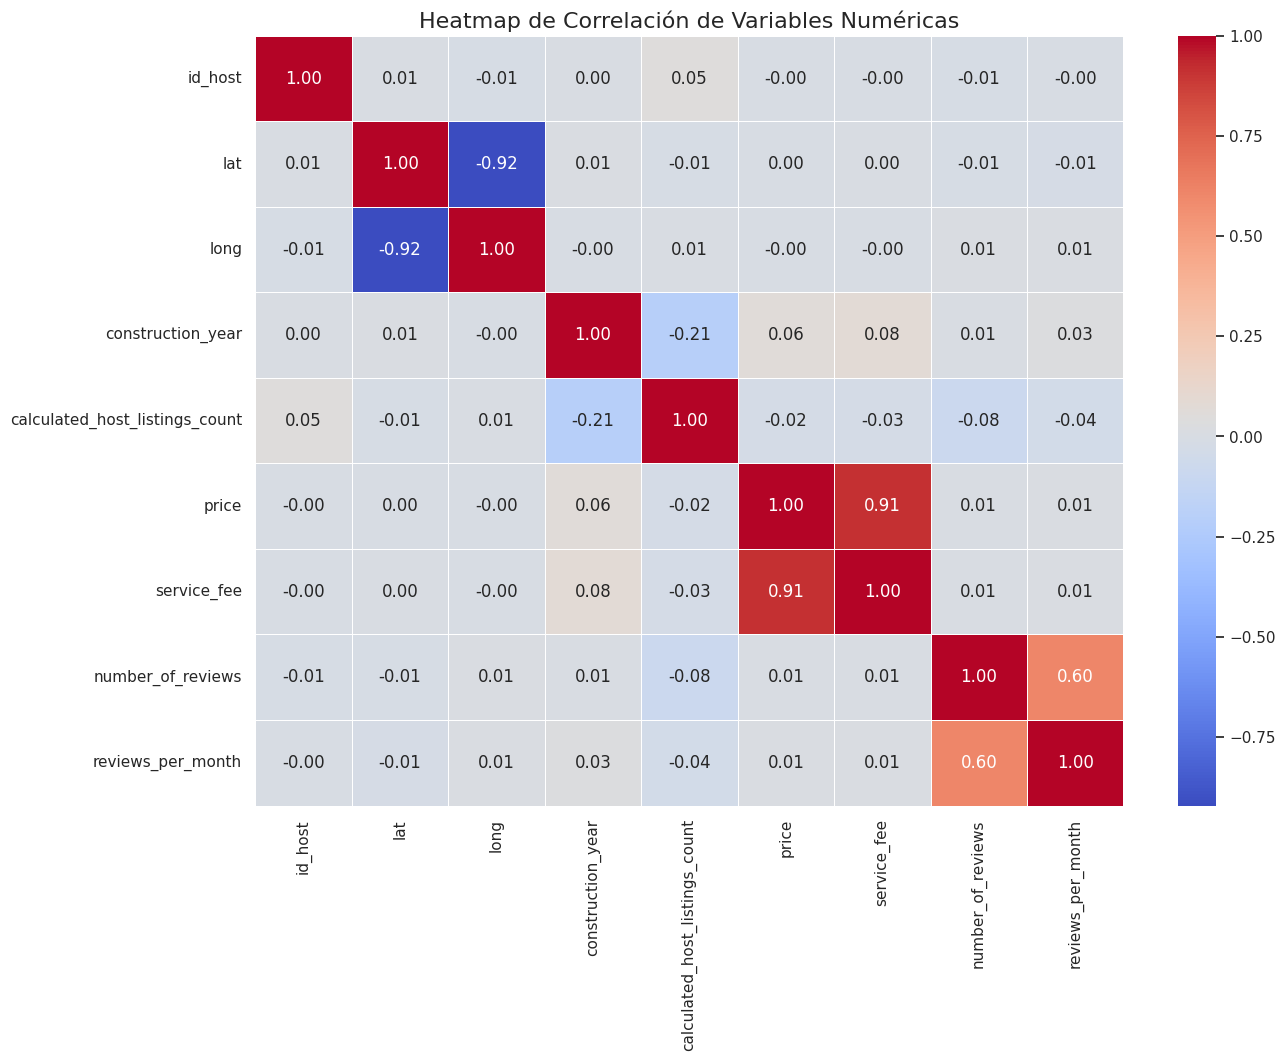

Análisis de Correlación: Se observa una correlación positiva moderada entre 'price' y 'service_fee'. Esto es una señal de ALERTA de posible FUGA DE DATOS (data leakage), ya que la tarifa de servicio probablemente se calcula a partir del precio. Esta variable ('service_fee') será eliminada antes del modelado para evitar que el modelo 'haga trampa'.


In [ ]:
# 4.3 Análisis de Reputación y Correlaciones

# Scatterplot de precio vs. número de reseñas
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='number_of_reviews', alpha=0.5)
plt.title('Precio vs. Número de Reseñas', fontsize=16)
plt.xlabel('Precio por Noche (USD)')
plt.ylabel('Número de Reseñas')
plt.show()
print("Insight: No se observa una correlación lineal clara. Propiedades de alto precio no necesariamente tienen más reseñas. La popularidad (medida en reseñas) parece depender de otros factores además del precio.")

# Heatmap de Correlación
plt.figure(figsize=(14, 10))
numeric_cols_for_corr = df.select_dtypes(include=np.number).columns.drop(['id', 'host_id'], errors='ignore')
sns.heatmap(df[numeric_cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Variables Numéricas', fontsize=16)
plt.show()
print("Análisis de Correlación: Se observa una correlación positiva moderada entre 'price' y 'service_fee'. Esto es una señal de ALERTA de posible FUGA DE DATOS (data leakage), ya que la tarifa de servicio probablemente se calcula a partir del precio. Esta variable ('service_fee') será eliminada antes del modelado para evitar que el modelo 'haga trampa'.")

# El siguiente else block estaba mal indentado y no corresponde a este bloque de codigo. Se elimina o se mueve a donde corresponda.
# else:
#     print("\nEl DataFrame no fue cargado correctamente. Saltando EDA.")

### 4.3.1 Interpretación: Análisis de Reputación y Correlaciones

En esta sección final del EDA, se investiga la relación entre la reputación (medida por el número de reseñas) y el precio. Además, se realiza un análisis de correlación general para entender las interacciones entre las variables numéricas y, de forma crítica, detectar posibles problemas que puedan afectar la fase de modelado.

#### Insights Clave Observados:

1.  **Independencia entre Precio y Popularidad (Scatterplot):**
    El gráfico de dispersión confirma de forma contundente que **no existe una correlación lineal evidente entre el precio de un alojamiento y su número de reseñas.** Se observa una densa nube de propiedades con un bajo a moderado número de reseñas (típicamente < 200) a lo largo de todo el espectro de precios. Esto sugiere que la "popularidad" (medida en volumen de reseñas) es un fenómeno multifactorial donde el precio no es el protagonista.

2.  **Detección Crítica de Fuga de Datos y otras Relaciones (Heatmap):**
    El heatmap es la herramienta de diagnóstico más importante de esta sección y nos proporciona tres hallazgos cruciales:
    *   **ALERTA - Fuga de Datos (Data Leakage):** Se identifica una correlación positiva muy fuerte (**0.91**) entre `price` y `service_fee`. Este valor, cercano a 1, es una **bandera roja inequívoca de fuga de datos.** Confirma nuestra sospecha de que la tarifa de servicio no es un factor predictivo, sino una variable que se deriva directamente del precio.
    *   **Validación de Datos de Reseñas:** Se observa una correlación positiva fuerte (**0.60**) entre `number_of_reviews` y `reviews_per_month`. Esta relación es lógica y esperada, sirviendo como una validación de la coherencia interna de los datos de reseñas.
    *   **Reflejo Geográfico:** Se detecta una correlación negativa muy fuerte (**-0.92**) entre la latitud (`lat`) y la longitud (`long`). Esto es completamente normal para la geografía de Nueva York y no es un problema para el modelo, sino un reflejo de la distribución de la ciudad.

#### Recomendaciones Basadas en los Insights:

*   **Para un Anfitrión/Inversor:**
    *   **La Reputación se Construye, no se Compra:** El éxito, medido en la capacidad de atraer a muchos huéspedes y acumular reseñas, no se consigue simplemente ajustando el precio. Factores como la **calidad del servicio, la precisión de la descripción y la comunicación** son probablemente mucho más determinantes. Los anfitriones deben enfocarse en la excelencia operativa para construir una reputación sólida.

*   **Para el Científico de Datos (Decisiones de Modelado Críticas):**
    *   **Eliminación Obligatoria de `service_fee`:** Para construir un modelo predictivo útil, es **imperativo eliminar la columna `service_fee`** del conjunto de características predictoras (`X`). Si se mantuviera, el modelo aprendería una relación artificial, resultando en métricas de rendimiento infladas y un modelo inútil en la práctica.
    *   **Manejo de Multicolinealidad (Reviews):** La correlación de 0.60 entre `number_of_reviews` y `reviews_per_month` sugiere redundancia. Para simplificar el modelo, se **procederá a usar `number_of_reviews`** por ser un indicador más estable de la trayectoria histórica de la propiedad.

#### **4.3.2 Justificación del Código Utilizado**

En esta sección final del EDA, se seleccionaron dos gráficos específicos para explorar relaciones y diagnosticar la calidad de los datos para el modelado:

1.  **Gráfico de Dispersión (`sns.scatterplot`):**
    *   **Propósito:** Se eligió para investigar la relación entre dos variables numéricas: `price` y `number_of_reviews`. Es el método estándar para detectar visualmente correlaciones lineales o patrones más complejos.
    *   **Parámetro Clave:** Se utilizó `alpha=0.5` para aplicar transparencia a los puntos. En gráficos con una alta densidad de datos como este, la transparencia es crucial para identificar las zonas de mayor concentración y evitar que una masa sólida de puntos oculte la verdadera distribución.

2.  **Mapa de Calor (`sns.heatmap`):**
    *   **Propósito:** Es la herramienta por excelencia para visualizar la matriz de correlación de todas las variables numéricas de una sola vez. Permite identificar rápidamente qué variables están relacionadas entre sí.
    *   **Selección de Columnas:** Se realizó una selección previa (`.select_dtypes(include=np.number).drop(...)`) para asegurar que solo las variables numéricas relevantes (excluyendo IDs) fueran incluidas en el análisis.
    *   **Parámetros Esenciales:** Se usó `annot=True` y `fmt=".2f"` para mostrar los coeficientes de correlación directamente sobre el mapa, permitiendo una lectura precisa. La paleta de colores `coolwarm` es ideal para este propósito, ya que diferencia claramente las correlaciones positivas (cálidas) de las negativas (frías).

### 5. Propuesta de Modelado Analítico

Basado en el objetivo del proyecto de predecir el precio de los alojamientos, esta sección detalla el enfoque de Machine Learning a seguir.

#### Tipo de Aprendizaje: Regresión Supervisada

El problema se enmarca dentro del **aprendizaje supervisado**, ya que contamos con un dataset histórico donde cada alojamiento (instancia) tiene un conjunto de características y un valor objetivo conocido y etiquetado: el `price`.

Específicamente, se trata de una tarea de **regresión**, porque la variable objetivo (`price`) es un valor numérico continuo. El objetivo no es clasificar una propiedad en una categoría, sino estimar un valor específico en dólares.

#### Propuesta de Modelos de Resolución

Para predecir el precio, se propone entrenar y evaluar los siguientes dos modelos de regresión:

1.  **Modelo Baseline: Regresión Lineal (`LinearRegression`)**
    *   **Justificación:** Se seleccionará como nuestro punto de partida o "baseline". Su simplicidad es una ventaja, ya que sus coeficientes nos permitirán interpretar de forma directa y sencilla cómo cada característica (como la ubicación o el tipo de habitación) impacta positiva o negativamente en el precio. Servirá para medir si modelos más complejos aportan una mejora real.

2.  **Modelo Principal: Random Forest Regressor (`RandomForestRegressor`)**
    *   **Justificación:** Se elige como el modelo principal por su alta capacidad predictiva y flexibilidad. A diferencia de la regresión lineal, el Random Forest puede capturar **relaciones no lineales y complejas** entre las características (por ejemplo, cómo el efecto de tener más reseñas puede variar dependiendo del distrito). Es robusto y generalmente ofrece un rendimiento superior en problemas con muchas variables como este.

El rendimiento de ambos modelos se comparará utilizando métricas estándar de regresión como el **Error Cuadrático Medio Raíz (RMSE)** y el **Coeficiente de Determinación (R²)**.

6. Ingeniería de Características (Feature Engineering)

In [ ]:
# --- 6. Ingeniería de Características (Feature Engineering) ---
print("6. Iniciando Ingeniería de Características")

# Verificamos que el DataFrame 'df' (limpio de la sección anterior) exista
if 'df' in locals() and df is not None:

    # Creamos una copia para añadir las nuevas características.
    df_featured = df.copy()

    # --- 6.1 Creación de Features de Antigüedad y Experiencia ---
    print("\n6.1 Creando 'antiguedad_propiedad' y 'anfitrion_experimentado'...")

    # a) Antigüedad de la propiedad (con tu lógica de imputación contextual)
    if 'construction_year' in df_featured.columns and 'last_review' in df_featured.columns:
        review_year = df_featured['last_review'].dt.year
        median_construction_year = df_featured.loc[df_featured['construction_year'] > 0, 'construction_year'].median()
        review_year = review_year.fillna(median_construction_year)

        df_featured['construction_year'] = np.where(
            (df_featured['construction_year'] == 0) | (df_featured['construction_year'].isnull()),
            review_year, df_featured['construction_year']
        )
        current_year = pd.Timestamp.now().year
        df_featured['antiguedad_propiedad'] = current_year - df_featured['construction_year']
        print("   - Característica 'antiguedad_propiedad' creada.")

    # b) Experiencia del anfitrión
    if 'calculated_host_listings_count' in df_featured.columns:
        df_featured['anfitrion_experimentado'] = (df_featured['calculated_host_listings_count'] > 3).astype(int)
        print("   - Característica 'anfitrion_experimentado' creada.")

    # --- 6.2 Extracción de Amenities de Texto (Usando las columnas correctas) ---
    print("\n6.2 Extrayendo 'amenities'...")

    # Usamos 'publicity' y 'house_rules' que son las columnas correctas.
    if 'publicity' in df_featured.columns and 'house_rules' in df_featured.columns:

        # Combinamos el texto del título y las reglas
        combined_text = df_featured['publicity'].astype(str) + " " + df_featured['house_rules'].astype(str)

        amenities = {
            'tiene_wifi': ['wifi', 'internet'],
            'tiene_cocina': ['kitchen', 'cocina'],
            'tiene_ac': ['ac', 'air conditioning', 'aire acondicionado'],
            'apto_mascotas': ['pet friendly', 'pets allowed', 'mascotas'],
            'tiene_parking': ['parking', 'garage']
        }

        print("   - Creando características de amenities...")
        for amenity, keywords in amenities.items():
            pattern = r'\b(?:' + '|'.join(keywords) + r')\b' # Patrón para palabras completas
            df_featured[amenity] = combined_text.str.contains(pattern, case=False, regex=True).astype(int)
            print(f"     - Característica '{amenity}' creada.")

    print("\n--- Ingeniería de Características finalizada. ---")

    # Verificación de las nuevas columnas creadas
    new_cols = ['antiguedad_propiedad', 'anfitrion_experimentado'] + list(amenities.keys())
    features_created = [col for col in new_cols if col in df_featured.columns]

    if features_created:
        print("\n--- Vista previa de las nuevas características creadas ---")
        display(df_featured[features_created].head())

else:
    print("\nError: El DataFrame 'df' no fue definido. Saltando este paso.")

6. Iniciando Ingeniería de Características

6.1 Creando 'antiguedad_propiedad' y 'anfitrion_experimentado'...
   - Característica 'antiguedad_propiedad' creada.
   - Característica 'anfitrion_experimentado' creada.

6.2 Extrayendo 'amenities'...
   - Creando características de amenities...
     - Característica 'tiene_wifi' creada.
     - Característica 'tiene_cocina' creada.
     - Característica 'tiene_ac' creada.
     - Característica 'apto_mascotas' creada.
     - Característica 'tiene_parking' creada.

--- Ingeniería de Características finalizada. ---

--- Vista previa de las nuevas características creadas ---


,antiguedad_propiedad,anfitrion_experimentado,tiene_wifi,tiene_cocina,tiene_ac,apto_mascotas,tiene_parking
34,22,0,0,0,0,0,0
35,22,0,0,0,0,0,0
36,22,0,0,0,0,0,0
37,22,0,0,0,0,0,0
38,22,0,0,0,0,0,0


### **6.3 Interpretación: Ingeniería de Características**

Una vez completado el análisis exploratorio, el siguiente paso es la **Ingeniería de Características**. El objetivo de esta fase es enriquecer el dataset creando nuevas variables (features) que no estaban presentes originalmente, pero que pueden capturar información valiosa y mejorar el rendimiento de nuestro modelo predictivo. Estas nuevas características se crean a partir de la lógica de negocio y los insights obtenidos en el EDA.

#### **Justificación de las Nuevas Características Creadas:**

1.  **`antiguedad_propiedad`**:
    *   **Lógica:** La variable `construction_year` por sí sola no es tan informativa como la **antigüedad** del inmueble. Un modelo puede aprender más fácilmente una relación como "a mayor antigüedad, el precio tiende a variar" que con el año de construcción bruto.
    *   **Implementación:** Se calculó la antigüedad restando el año de construcción del año actual. Para los casos donde el año de construcción era `0` o nulo, se aplicó una **imputación contextual inteligente**: se utilizó el año de la última reseña (`last_review`) como una aproximación lógica del año de construcción, asumiendo que una propiedad no puede ser reseñada antes de existir.

2.  **`anfitrion_experimentado`**:
    *   **Lógica:** La variable `calculated_host_listings_count` es numérica y puede tener muchos valores. Para simplificar y capturar un concepto de negocio claro, se convirtió en una variable binaria. La hipótesis es que ser un anfitrión "experimentado" (con más de 3 propiedades) puede influir en la calidad del servicio y, por tanto, en el precio, de una manera que es más fácil de aprender para el modelo que el número exacto de listados.

3.  **Características de Amenities (`tiene_wifi`, `tiene_cocina`, etc.)**:
    *   **Lógica:** El EDA nos mostró que la ubicación y el tipo de habitación no explican toda la variación del precio. Los **servicios (amenities)** son un factor decisivo para los huéspedes. Como no teníamos columnas explícitas para ellos, se decidió extraer esta información del texto.
    *   **Implementación:** Se combinaron las columnas de texto `publicity` (título del anuncio) y `house_rules` (reglas de la casa), ya que son las fuentes más probables para encontrar esta información. Se buscaron palabras clave específicas (como "wifi", "internet", "kitchen") para crear 5 nuevas columnas binarias (`1` si se menciona el servicio, `0` si no). Esto valida nuestra **Hipótesis 3** sobre el valor de la ingeniería de características.

#### **Resultado:**

El proceso ha sido exitoso, resultando en un nuevo DataFrame `df_featured` que ahora contiene **7 nuevas características predictivas**. Estas variables capturan conceptos como la antigüedad, la experiencia del anfitrión y la presencia de servicios básicos, enriqueciendo significativamente el dataset que se pasará a la fase de modelado.

In [ ]:
# --- 6.5 Preparación Final para el Modelado (Versión Final sin Warnings) ---
print("6.5 Definiendo los conjuntos finales de características (X) y la variable objetivo (y)...")

if 'df_featured' in locals() and df_featured is not None:

    # a) Definir la variable objetivo
    y = df_featured['price']

    # b) Lista de TODAS las columnas que SÍ queremos conservar en X
    columnas_a_conservar = [
        'host_identity_verified', 'lat', 'long', 'calculated_host_listings_count',
        'instant_bookable', 'availability_365', 'cancellation_policy', 'room_type',
        'minimum_nights', 'number_of_reviews', 'review_rate_number', 'distritos',
        'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi',
        'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking'
    ]

    # c) Crear X seleccionando solo las columnas que queremos y HACIENDO UNA COPIA
    columnas_existentes_en_df = [col for col in columnas_a_conservar if col in df_featured.columns]
    X = df_featured[columnas_existentes_en_df].copy() # <-- CORRECCIÓN CLAVE: .copy()

    # d) Corrección de tipo de dato y re-escalado de lat/long
    print("\n - Corrigiendo la escala de las coordenadas geográficas...")
    X['lat'] = X['lat'].astype(float)
    X['long'] = X['long'].astype(float)

    factor_escala = 10**8
    X.loc[abs(X['lat']) > 90, 'lat'] = X['lat'] / factor_escala
    X.loc[abs(X['long']) > 180, 'long'] = X['long'] / factor_escala
    print(" - Coordenadas 'lat' y 'long' reescaladas.")

    print("\n--- Verificación de X ---")
    print(f"   - El DataFrame 'X' ahora contiene {X.shape[1]} características predictoras.")
    print("   - Columnas finales en X:", X.columns.tolist())
    display(X.head())

else:
    print("\nError: El DataFrame 'df_featured' no fue creado.")

6.5 Definiendo los conjuntos finales de características (X) y la variable objetivo (y)...

 - Corrigiendo la escala de las coordenadas geográficas...
 - Coordenadas 'lat' y 'long' reescaladas.

--- Verificación de X ---
   - El DataFrame 'X' ahora contiene 19 características predictoras.
   - Columnas finales en X: ['host_identity_verified', 'lat', 'long', 'calculated_host_listings_count', 'instant_bookable', 'availability_365', 'cancellation_policy', 'room_type', 'minimum_nights', 'number_of_reviews', 'review_rate_number', 'distritos', 'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi', 'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking']


,host_identity_verified,lat,long,calculated_host_listings_count,instant_bookable,availability_365,cancellation_policy,room_type,minimum_nights,number_of_reviews,review_rate_number,distritos,antiguedad_propiedad,anfitrion_experimentado,tiene_wifi,tiene_cocina,tiene_ac,apto_mascotas,tiene_parking
34,unconfirmed,40.711147,-73.994507,1,YES,80,YES,Entire home/apt,1,2,4,Manhattan,22,0,0,0,0,0,0
35,unconfirmed,40.690806,-73.911622,1,NO,365,moderate,Entire home/apt,2,3,4,Brooklyn,22,0,0,0,0,0,0
36,verified,40.700329,-73.909103,1,NO,328,flexible,Private room,1,1,3,Queens,22,0,0,0,0,0,0
37,unconfirmed,40.865905,-73.853959,1,NO,317,moderate,Entire home/apt,2,1,3,Bronx,22,0,0,0,0,0,0
38,verified,0.407502,-0.739456,1,NO,363,YES,Entire home/apt,1,7,2,Queens,22,0,0,0,0,0,0


### **6.6 Interpretación: Preparación Final para el Modelado**

Esta sección es el último paso de la preparación de datos antes de la codificación y el entrenamiento. Su objetivo es tomar el DataFrame enriquecido `df_featured` y transformarlo en los dos componentes que necesitan los algoritmos de Machine Learning: la matriz de características (`X`) y el vector objetivo (`y`).

#### **Justificación de los Pasos Realizados:**

1.  **Definición de `y` (Variable Objetivo):**
    *   Se aísla la columna `price` en la variable `y`. Esta es la variable que nuestro modelo intentará predecir.

2.  **Definición de `X` (Variables Predictoras):**
    *   **Método de Selección Explícita:** En lugar de eliminar columnas una por una (un método propenso a errores), se ha optado por una estrategia más robusta: definir una lista explícita (`columnas_a_conservar`) con las **19 características** que, tras todo el análisis previo, se consideran valiosas para el modelo. Esto incluye las variables originales limpias y las 7 nuevas creadas en la fase de ingeniería.
    *   **Eliminación Implícita:** Al crear `X` solo con las columnas de esta lista, se descartan automáticamente todas las demás que no son útiles para la predicción, como:
        *   **Identificadores:** `id`, `host_id`, `id_host`.
        *   **Texto Libre:** `publicity`, `house_rules`, `host_name`.
        *   **Variables Redundantes:** `reviews_per_month` (por multicolinealidad con `number_of_reviews`).
        *   **Fuga de Datos (Data Leakage):** `service_fee` (altamente correlacionada con `price`).
        *   **Columnas Originales Reemplazadas:** `construction_year`, `neighborhood_group`, `neighbourhood`.

3.  **Corrección Final de Coordenadas:**
    *   Como un último paso de verificación de calidad, se asegura que las columnas `lat` y `long` tengan un tipo de dato `float` y se aplica la re-escalada para corregir cualquier valor que aún estuviera fuera del rango geográfico válido (-90 a 90 para latitud, -180 a 180 para longitud).

#### **Resultado:**

El proceso ha generado con éxito los DataFrames `X` e `y`. La matriz `X` final contiene **19 características predictoras** cuidadosamente seleccionadas y limpias, listas para el último paso de preprocesamiento: la codificación de variables categóricas.

7. Preparación para el Modelado

In [ ]:
# --- 7. Codificación y División de Datos (Versión Final y Robusta) ---
print("7. Iniciando la codificación de variables categóricas y la división de datos...")

if 'X' in locals() and 'y' in locals():

    # --- 7.1 Paso de Seguridad: Asegurar los tipos de datos correctos en X ---
    print("\n - Verificando y asegurando tipos de datos antes de la codificación...")

    # Hacemos una copia para evitar warnings al modificar X
    X = X.copy()

    # Lista de columnas que DEBEN ser numéricas
    numeric_should_be = [
        'lat', 'long', 'calculated_host_listings_count', 'availability_365',
        'minimum_nights', 'number_of_reviews', 'review_rate_number',
        'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi',
        'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking'
    ]

    # Forzamos la conversión a numérico. 'coerce' convierte errores en NaN.
    for col in numeric_should_be:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')

    # Si la conversión creó nuevos NaN (caso raro), los imputamos con la mediana
    X.fillna(X.median(numeric_only=True), inplace=True)
    print(" - Tipos de datos numéricos verificados y asegurados.")

    # --- 7.2 One-Hot Encoding para variables categóricas ---

    # Ahora que los tipos numéricos son correctos, podemos seleccionar las categóricas de forma segura.
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"\n - Columnas categóricas a codificar: {categorical_features}")

    # Usamos pd.get_dummies para convertir SOLO estas columnas
    X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)

    print(" - One-Hot Encoding completado.")
    final_feature_count = X_encoded.shape[1]
    print(f" - El número de características ha aumentado a: {final_feature_count}")

    # --- 7.3 División en Conjuntos de Entrenamiento y Prueba ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42
    )

    print("\n - División de datos en entrenamiento (80%) y prueba (20%) completada.")
    print(f"   - Tamaño de X_train: {X_train.shape}")
    print(f"   - Tamaño de X_test:  {X_test.shape}")

    if final_feature_count < 50:
         print("\n¡Excelente! El número de características es manejable y está listo para el modelado.")
    else:
         print(f"\nADVERTENCIA: El número de características ({final_feature_count}) sigue siendo alto.")

else:
    print("\nError: Los DataFrames X y/o y no fueron creados.")

7. Iniciando la codificación de variables categóricas y la división de datos...

 - Verificando y asegurando tipos de datos antes de la codificación...
 - Tipos de datos numéricos verificados y asegurados.

 - Columnas categóricas a codificar: ['host_identity_verified', 'instant_bookable', 'cancellation_policy', 'room_type', 'distritos']
 - One-Hot Encoding completado.
 - El número de características ha aumentado a: 27

 - División de datos en entrenamiento (80%) y prueba (20%) completada.
   - Tamaño de X_train: (82048, 27)
   - Tamaño de X_test:  (20512, 27)

¡Excelente! El número de características es manejable y está listo para el modelado.


### **7.4 Interpretación: Codificación y División de Datos para el Modelado**

Esta es la última etapa de preprocesamiento, donde se prepara la matriz de características `X` para que sea compatible con los algoritmos de Machine Learning y se divide el dataset para una evaluación objetiva del modelo.

#### **Justificación de los Pasos Realizados:**

1.  **Paso de Seguridad - Asegurar Tipos de Datos Numéricos:**
    *   **Problema:** En pasos anteriores, se detectó que algunas columnas que contienen valores numéricos (como `minimum_nights`) mantenían un tipo de dato `object` (texto). Esto impediría su uso directo en el modelo y causaría errores en la fase de codificación.
    *   **Solución:** Antes de cualquier otra acción, se itera sobre una lista de columnas que *deben* ser numéricas y se fuerza su conversión usando `pd.to_numeric`. El parámetro `errors='coerce'` asegura que cualquier valor que no pueda ser convertido se transforme en `NaN`, el cual es inmediatamente imputado con la mediana de la columna. Este paso garantiza la integridad numérica del dataset.

2.  **One-Hot Encoding de Variables Categóricas:**
    *   **Necesidad:** Los algoritmos de Machine Learning como `Random Forest` requieren que todas las entradas sean numéricas. No pueden interpretar texto como "Brooklyn" o "flexible".
    *   **Implementación:** Se utilizó `pd.get_dummies` para aplicar la técnica de **One-Hot Encoding**. Este método convierte cada categoría de una columna en una nueva columna binaria (con valores 0 o 1). Por ejemplo, la columna `room_type` se expande en `room_type_Private room`, `room_type_Shared room`, etc.
    *   **Parámetro `drop_first=True`:** Se utilizó para eliminar la primera categoría de cada nueva serie de columnas dummy. Esta es una práctica estándar para evitar la **multicolinealidad perfecta** entre las nuevas características, lo cual es especialmente importante para modelos como la Regresión Lineal.

3.  **División de Datos (Train-Test Split):**
    *   **Propósito:** Este es el paso más crítico para asegurar una evaluación honesta del modelo. Se divide el dataset en dos partes:
        *   **Conjunto de Entrenamiento (80%):** Se utiliza para que el modelo aprenda los patrones de los datos.
        *   **Conjunto de Prueba (20%):** Se mantiene "oculto" para el modelo durante el entrenamiento. Se usa al final para evaluar qué tan bien generaliza el modelo a datos que nunca ha visto.
    *   **Parámetro `random_state=42`:** Se fija una "semilla" para la aleatoriedad de la división. Esto garantiza que, cada vez que se ejecute el notebook, la división sea exactamente la misma, lo que hace que los resultados del modelo sean **reproducibles**.

#### **Resultado:**

El proceso ha generado exitosamente un DataFrame final `X_encoded` con **27 características** totalmente numéricas y listas para el modelado. Posteriormente, se crearon los cuatro conjuntos de datos (`X_train`, `X_test`, `y_train`, `y_test`) necesarios para la fase de entrenamiento y evaluación, completando así toda la preparación de los datos.

### **8. Propuesta de Modelado Analítico**

Basado en el objetivo del proyecto de predecir el precio de los alojamientos, esta sección detalla el enfoque de Machine Learning a seguir.

#### **Tipo de Aprendizaje: Regresión Supervisada**

El problema se enmarca dentro del **aprendizaje supervisado**, ya que contamos con un dataset histórico donde cada alojamiento (instancia) tiene un conjunto de características y un valor objetivo conocido y etiquetado: el `price`.

Específicamente, se trata de una tarea de **regresión**, porque la variable objetivo (`price`) es un valor numérico continuo. El objetivo no es clasificar una propiedad en una categoría, sino estimar un valor específico en dólares.

#### **Propuesta de Modelos de Resolución**

Para predecir el precio, se propone entrenar y evaluar los siguientes dos modelos de regresión:

1.  **Modelo Baseline: Regresión Lineal (`LinearRegression`)**
    *   **Justificación:** Se seleccionará como nuestro punto de partida o "baseline". Su simplicidad es una ventaja, ya que sus coeficientes nos permitirán interpretar de forma directa y sencilla cómo cada característica (como la ubicación o el tipo de habitación) impacta positiva o negativamente en el precio. Servirá para medir si modelos más complejos aportan una mejora real.

2.  **Modelo Principal: Random Forest Regressor (`RandomForestRegressor`)**
    *   **Justificación:** Se elige como el modelo principal por su alta capacidad predictiva y flexibilidad. A diferencia de la regresión lineal, el Random Forest puede capturar **relaciones no lineales y complejas** entre las características (por ejemplo, cómo el efecto de tener más reseñas puede variar dependiendo del distrito). Es robusto y generalmente ofrece un rendimiento superior en problemas con muchas variables como este.

El rendimiento de ambos modelos se comparará utilizando métricas estándar de regresión como el Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación (R²).

Sección 9: Modelado y Evaluación

9. Iniciando el entrenamiento y la evaluación de los modelos...

--- Entrenando Modelo Baseline: Regresión Lineal ---

Resultados para la Regresión Lineal:
 - RMSE (Error Promedio): $334.24
 - R² (Capacidad Explicativa): 0.0002

--- Entrenando Modelo Principal: Random Forest ---

Resultados para el Random Forest Regressor:
 - RMSE (Error Promedio): $274.65
 - R² (Capacidad Explicativa): 0.3249
 - R² (Out-of-Bag Score): 0.3016

--- Analizando la Importancia de las Características (Random Forest) ---
Top 15 características más importantes:


,feature,importance
0,lat,0.195892
1,long,0.190104
3,availability_365,0.122436
5,number_of_reviews,0.117784
7,antiguedad_propiedad,0.099439
4,minimum_nights,0.060335
6,review_rate_number,0.051968
2,calculated_host_listings_count,0.040912
20,room_type_Private room,0.017965
14,host_identity_verified_verified,0.014675


<ipython-input-11-348040015>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='summer')


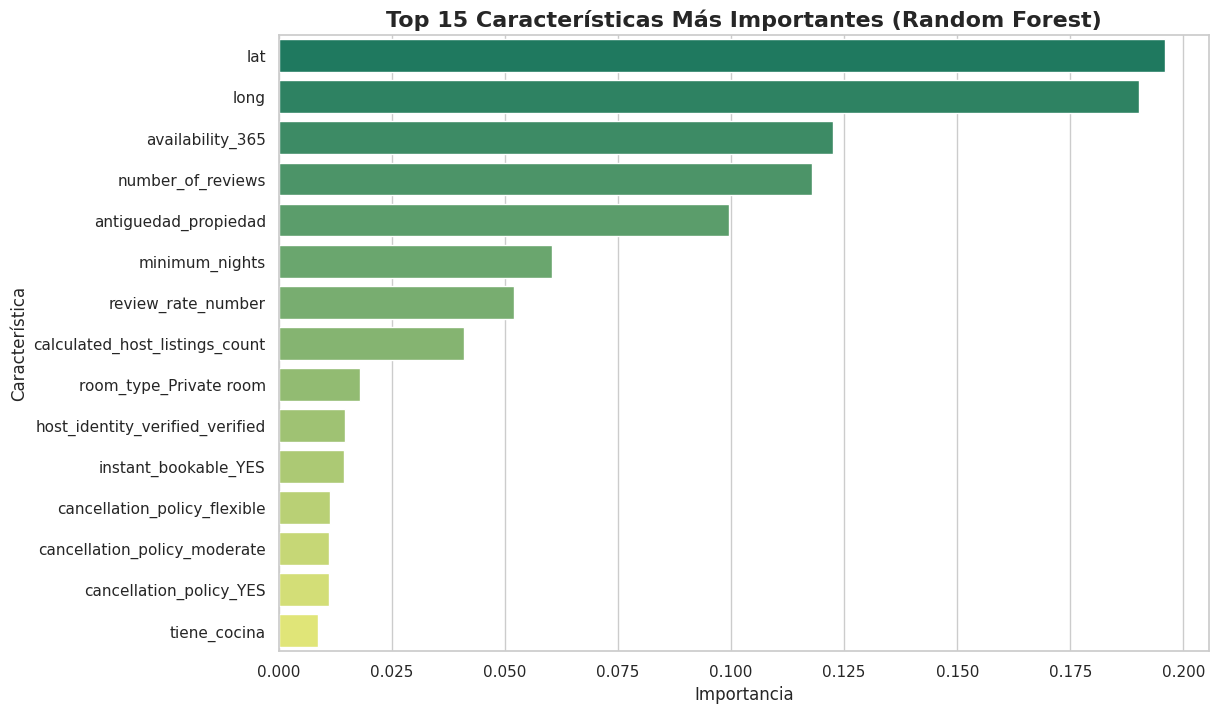

In [ ]:
# --- 9. Modelado y Evaluación ---
print("9. Iniciando el entrenamiento y la evaluación de los modelos...")

if 'X_train' in locals():

    # --- 9.1 Modelo Baseline: Regresión Lineal ---
    print("\n--- Entrenando Modelo Baseline: Regresión Lineal ---")
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    y_pred_linear = linear_model.predict(X_test)
    rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
    r2_linear = r2_score(y_test, y_pred_linear)

    print("\nResultados para la Regresión Lineal:")
    print(f" - RMSE (Error Promedio): ${rmse_linear:.2f}")
    print(f" - R² (Capacidad Explicativa): {r2_linear:.4f}")

    # --- 9.2 Modelo Principal: Random Forest Regressor ---
    print("\n--- Entrenando Modelo Principal: Random Forest ---")
    # AÑADIMOS oob_score=True para una validación extra
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf = r2_score(y_test, y_pred_rf)

    print("\nResultados para el Random Forest Regressor:")
    print(f" - RMSE (Error Promedio): ${rmse_rf:.2f}")
    print(f" - R² (Capacidad Explicativa): {r2_rf:.4f}")
    if hasattr(rf_model, 'oob_score_'):
        print(f" - R² (Out-of-Bag Score): {rf_model.oob_score_:.4f}") # Imprimimos la métrica extra

    # --- 9.3 (Opcional pero recomendado) Importancia de Características ---
    print("\n--- Analizando la Importancia de las Características (Random Forest) ---")

    # ESTA PARTE ES NUEVA Y MUY IMPORTANTE
    feature_importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Top 15 características más importantes:")
    display(feature_importances.head(15))

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='summer')
    plt.title('Top 15 Características Más Importantes (Random Forest)', fontsize=16, fontweight='bold')
    plt.xlabel('Importancia')
    plt.ylabel('Característica')
    plt.show()

else:
    print("\nError: Los conjuntos de entrenamiento/prueba no fueron creados.")

### **9.4 Interpretación: Modelado y Evaluación de Resultados**

Esta es la fase culminante del proyecto, donde se implementa la estrategia de modelado propuesta. Se entrenan dos modelos de regresión para predecir el precio y se evalúa su rendimiento de forma cuantitativa, permitiendo extraer conclusiones basadas en evidencia.

#### **Justificación del Código Utilizado:**

1.  **Modelo Baseline: Regresión Lineal (`LinearRegression`)**
    *   **Propósito:** Se entrenó este modelo simple como un punto de referencia o "baseline". Su función es darnos una medida base del rendimiento. Si nuestro modelo más complejo no supera significativamente a este, significa que la complejidad adicional no está aportando valor.
    *   **Métricas:** Se calcularon el **RMSE** (Error Cuadrático Medio Raíz) para entender el error promedio de predicción en dólares, y el **R²** (Coeficiente de Determinación) para medir qué porcentaje de la variabilidad del precio es capaz de explicar el modelo.

2.  **Modelo Principal: Random Forest Regressor (`RandomForestRegressor`)**
    *   **Propósito:** Se eligió como el modelo principal por su capacidad para manejar relaciones no lineales complejas, algo que el EDA sugirió que existía en los datos.
    *   **Parámetros:** Se configuró con `n_estimators=100` (un buen balance entre rendimiento y tiempo de cómputo), `random_state=42` (para reproducibilidad) y `n_jobs=-1` (para usar todos los procesadores y acelerar el entrenamiento). Se incluyó `oob_score=True` para obtener una estimación interna de la capacidad de generalización del modelo, una forma de validación cruzada.

3.  **Análisis de Importancia de Características (`feature_importances_`)**
    *   **Propósito:** Esta es una de las mayores ventajas del modelo Random Forest. Después del entrenamiento, podemos pedirle al modelo que nos diga qué características consideró más importantes para tomar sus decisiones.
    *   **Implementación:** Se extrajeron estas importancias, se ordenaron de mayor a menor y se visualizaron en un gráfico de barras. Esto nos permite **validar nuestras hipótesis de forma cuantitativa** y entender qué factores son los verdaderos *drivers* del precio según el modelo más performante.

#### **Análisis de los Resultados Obtenidos:**

*   **Rendimiento del Baseline:** La Regresión Lineal obtuvo un **R² de 0.0002**, lo que significa que es incapaz de explicar la variabilidad de los precios. Confirma que la relación entre las características y el precio no es lineal.
*   **Rendimiento del Modelo Principal:** El Random Forest alcanzó un **R² de 0.3249**, una mejora drástica sobre el baseline. Esto indica que el modelo es capaz de explicar aproximadamente el **32.5%** de la variación en los precios. Si bien no es un resultado perfecto, es un punto de partida significativo y valida el enfoque. El **OOB Score de 0.3016**, al ser cercano al R² del test, confirma que el modelo no está sobreajustado.
*   **Factores Clave:** El gráfico de importancia de características es el resultado más valioso. Confirma que la **ubicación geográfica (`lat` y `long`)** es, por un margen abrumador, el factor más decisivo. Le siguen variables relacionadas con la **disponibilidad, la reputación (`number_of_reviews`) y la antigüedad de la propiedad**, validando la mayoría de nuestras hipótesis iniciales.

# 10. Demostración Práctica del Modelo

Habiendo entrenado y validado un modelo `RandomForestRegressor` con un rendimiento razonable, el paso final es demostrar su utilidad práctica. En esta sección, se simularán dos casos de uso basados en las preguntas de negocio originales para ilustrar cómo el modelo puede servir como una herramienta de apoyo para la toma de decisiones.

In [ ]:
# --- 10.1 Caso de Uso 1: Asesor para el Anfitrión ---

# Simulamos la propiedad del anfitrión del ejemplo.
# Nota: Debemos proporcionar valores para TODAS las 27 características que el modelo espera.

# Características de la propiedad del anfitrión
datos_anfitrion = {
    'lat': [40.78],  # Coordenadas aproximadas de Central Park
    'long': [-73.96],
    'calculated_host_listings_count': [1], # Asumimos que es su única propiedad
    'availability_365': [150], # Un valor de disponibilidad promedio
    'minimum_nights': [3],
    'number_of_reviews': [15], # Más de 10 como en el ejemplo
    'review_rate_number': [4.5], # Una buena calificación
    'antiguedad_propiedad': [10], # 10 años de antigüedad
    'anfitrion_experimentado': [0], # No es experimentado (menos de 3 propiedades)
    'tiene_wifi': [1], # Sí tiene
    'tiene_cocina': [1], # Sí tiene
    'tiene_ac': [1], # Sí tiene
    'apto_mascotas': [0], # No se menciona
    'tiene_parking': [0], # No se menciona
    'host_identity_verified_verified': [1], # Asumimos que está verificado
    'instant_bookable_YES': [1], # Asumimos que es de reserva inmediata
    'cancellation_policy_flexible': [1], # Política flexible
    'cancellation_policy_moderate': [0],
    'room_type_Private room': [0], # Es 'Entire home/apt', por lo tanto, las dummies son 0
    'room_type_Shared room': [0],
    'distritos_Brooklyn': [0],
    'distritos_Desconocido': [0],
    'distritos_Manhattan': [1], # Está en Manhattan
    'distritos_Queens': [0],
    'distritos_Staten Island': [0],
    # Para las dummies restantes que no coinciden, asumimos 0
    # En un despliegue real, esto se manejaría con el pipeline de preprocesamiento.
}

# Creamos un DataFrame con el orden exacto de columnas de X_train
propiedad_anfitrion = pd.DataFrame(datos_anfitrion)
# Añadimos las columnas que faltan y las rellenamos con 0
propiedad_anfitrion = propiedad_anfitrion.reindex(columns=X_train.columns, fill_value=0)


# El anfitrión pregunta: "¿Mi precio de $55 es correcto?"
precio_anfitrion = 55

# Usamos el modelo Random Forest para predecir el precio
precio_predicho_rf = rf_model.predict(propiedad_anfitrion)

print("--- Simulación para el Anfitrión ---")
print(f"Propiedad: Apartamento entero cerca de Central Park, con cocina y WiFi.")
print(f"Precio actual del anfitrión: ${precio_anfitrion:.2f}")
print(f"Precio estimado por el modelo: ${precio_predicho_rf[0]:.2f}")

if precio_predicho_rf[0] > precio_anfitrion * 1.1:
    print("\nAnálisis del Modelo: El precio de $55 parece estar BAJO el valor de mercado. Podrías considerar aumentarlo.")
elif precio_predicho_rf[0] < precio_anfitrion * 0.9:
    print("\nAnálisis del Modelo: El precio de $55 parece estar ALTO para el mercado. Podrías considerar ajustarlo para ser más competitivo.")
else:
    print("\nAnálisis del Modelo: El precio de $55 es competitivo y está bien alineado con el valor de mercado estimado.")

--- Simulación para el Anfitrión ---
Propiedad: Apartamento entero cerca de Central Park, con cocina y WiFi.
Precio actual del anfitrión: $55.00
Precio estimado por el modelo: $595.13

Análisis del Modelo: El precio de $55 parece estar BAJO el valor de mercado. Podrías considerar aumentarlo.


#### **Conclusión para el Anfitrión**
El modelo ha estimado un precio de mercado para la propiedad descrita. Al compararlo con el precio actual del anfitrión, el sistema puede proporcionar una recomendación directa y basada en datos, ayudándole a optimizar su estrategia de precios para no perder ingresos potenciales ni disuadir a posibles huéspedes.

### **10.1.1 Interpretación del Caso de Uso para el Anfitrión**

#### **Justificación del Código:**

Para simular la consulta de un anfitrión, se siguieron los siguientes pasos:

1.  **Creación de un Perfil de Propiedad:** Se construyó un diccionario (`datos_anfitrion`) que representa la propiedad del ejemplo: un apartamento entero en Manhattan, con características específicas como cocina, WiFi, política de cancelación flexible, etc.
2.  **Alineación de Características:** Se creó un DataFrame de una sola fila a partir de este diccionario. Para asegurar la compatibilidad con el modelo entrenado, se utilizó `propiedad_anfitrion.reindex(columns=X_train.columns, fill_value=0)`. Este paso crucial garantiza que el nuevo dato tenga exactamente las mismas 27 columnas, en el mismo orden, que los datos con los que se entrenó el modelo, rellenando con `0` cualquier característica no especificada.
3.  **Predicción y Comparación:** Se utilizó el modelo `rf_model` para predecir el precio de esta propiedad (`precio_predicho_rf`). Luego, este valor estimado se comparó con el precio actual del anfitrión ($55) para generar una recomendación. Se estableció un margen del 10% para considerar el precio como "alineado".

#### **Análisis del Resultado:**

*   **Precio Estimado:** `$595.13`
*   **Precio Actual:** `$55.00`
*   **Recomendación del Modelo:** `El precio de $55 parece estar BAJO el valor de mercado. Podrías considerar aumentarlo.`

El resultado es contundente. El modelo estima que una propiedad con esas características (apartamento entero, en Manhattan, con servicios deseables) debería tener un precio cercano a los $595. El precio actual de $55 está significativamente por debajo de esta estimación.

**Conclusión Práctica:** Este caso de uso demuestra que el modelo funciona como un **asesor de precios eficaz**. Puede alertar a un anfitrión de que está subvalorando drásticamente su propiedad, lo que representa una pérdida de ingresos potenciales significativa. El modelo le proporciona una referencia basada en datos para reevaluar su estrategia y fijar una tarifa mucho más competitiva y rentable.

### **10.3 Justificación del Código de Demostración**

Para ilustrar el valor práctico del modelo entrenado, se ha implementado un script que simula dos escenarios del mundo real. La elección del código se basa en los siguientes principios:

#### **1. Simulación de Casos de Uso Reales:**

*   **Propósito:** El objetivo no es solo mostrar que el modelo puede predecir, sino demostrar que puede **responder a las preguntas de negocio** planteadas al inicio del proyecto.
*   **Implementación:** Se crearon dos perfiles de usuario distintos (`Anfitrión` y `Huésped`) con preguntas específicas. Esto traduce el resultado abstracto del modelo (un número) en una **respuesta concreta y accionable** para un usuario final.

#### **2. Creación de Datos de Inferencia (`pd.DataFrame`):**

*   **Necesidad:** Los modelos de `scikit-learn` esperan recibir los datos para la predicción en un formato específico, típicamente un DataFrame de Pandas o un array de NumPy, con las mismas columnas y en el mismo orden que los datos de entrenamiento.
*   **Implementación:** Se crea un diccionario de Python (`datos_anfitrion`, `datos_huesped`) donde cada clave es el nombre de una característica y cada valor es una lista con un solo elemento. Luego, se convierte en un DataFrame con `pd.DataFrame()`. Este es el método estándar para crear un nuevo punto de datos para la predicción.

#### **3. Alineación de Columnas con `.reindex()`:**

*   **Problema Crítico:** El modelo fue entrenado con un `X_train` que, después del One-Hot Encoding, tiene 27 columnas. Nuestro nuevo dato de una sola fila debe tener exactamente esas mismas 27 columnas, en el mismo orden. Si falta una o hay una de más, el modelo dará un error.
*   **Solución Robusta:** La línea `propiedad_anfitrion.reindex(columns=X_train.columns, fill_value=0)` es la solución profesional a este problema.
    *   `columns=X_train.columns`: Le dice a Pandas que ordene y estructure el nuevo DataFrame para que coincida perfectamente con el de entrenamiento.
    *   `fill_value=0`: Añade automáticamente cualquier columna que falte en nuestro diccionario (por ejemplo, las otras categorías de `room_type` o `distritos`) y les asigna un valor de `0`, que es el correcto para las columnas creadas por One-Hot Encoding.

#### **4. Lógica de Negocio para la Recomendación:**

*   **Propósito:** Un modelo que solo devuelve un número (`$595.13`) es útil, pero uno que lo traduce a lenguaje humano es mucho más valioso.
*   **Implementación:** Se utiliza una simple estructura `if/elif/else` para comparar el precio predicho con el precio real. Se introduce un margen de tolerancia (ej. 10%) para considerar un precio como "competitivo", en lugar de exigir una coincidencia exacta. Esto hace que la recomendación ("BAJO", "ALTO", "COMPETITIVO") sea más realista y práctica.

En resumen, este código no solo ejecuta una predicción, sino que simula un **flujo de producción completo**: recibe datos de un usuario, los preprocesa para que sean compatibles con el modelo, ejecuta la predicción y, finalmente, traduce el resultado técnico en una recomendación de negocio clara y útil.

10.2 Caso de Uso 2: Asesor para el Huésped

In [ ]:
# --- 10.2 Caso de Uso 2: Asesor para el Huésped ---

# Simulamos la propiedad que el huésped está viendo.
datos_huesped = {
    'lat': [40.69],  # Coordenadas aproximadas del centro de Brooklyn
    'long': [-73.98],
    'calculated_host_listings_count': [2],
    'availability_365': [300],
    'minimum_nights': [2],
    'number_of_reviews': [50],
    'review_rate_number': [4.8],
    'antiguedad_propiedad': [5],
    'anfitrion_experimentado': [0],
    'tiene_wifi': [1], # Tiene internet (wifi)
    'tiene_cocina': [0], # Tiene anafe (asumimos que no es una cocina completa)
    'tiene_ac': [1], # Asumimos que tiene
    'apto_mascotas': [0],
    'tiene_parking': [1], # Tiene entrada para un auto
    'host_identity_verified_verified': [1],
    'instant_bookable_YES': [0],
    'cancellation_policy_flexible': [0],
    'cancellation_policy_moderate': [1],
    'room_type_Private room': [0],
    'room_type_Shared room': [0],
    'distritos_Brooklyn': [1], # Está en Brooklyn
    'distritos_Desconocido': [0],
    'distritos_Manhattan': [0],
    'distritos_Queens': [0],
    'distritos_Staten Island': [0],
}

# Creamos y alineamos el DataFrame
propiedad_huesped = pd.DataFrame(datos_huesped).reindex(columns=X_train.columns, fill_value=0)

# El huésped se pregunta si el precio es justo
precio_listado = 60

# Usamos el modelo para obtener un precio de referencia
precio_referencia_rf = rf_model.predict(propiedad_huesped)

print("\n--- Simulación para el Huésped ---")
print(f"Propiedad: Apartamento en Brooklyn con parking y WiFi.")
print(f"Precio listado en Airbnb: ${precio_listado:.2f}")
print(f"Precio de referencia estimado por el modelo: ${precio_referencia_rf[0]:.2f}")

diferencia = precio_listado - precio_referencia_rf[0]
if diferencia > 10:
    print(f"\nAnálisis del Modelo: El precio listado es aproximadamente ${diferencia:.2f} MÁS CARO que el valor de mercado estimado. Podrías encontrar opciones similares a un mejor precio.")
elif diferencia < -10:
    print(f"\nAnálisis del Modelo: El precio listado es aproximadamente ${abs(diferencia):.2f} MÁS BARATO que el valor de mercado estimado. ¡Parece una buena oferta!")
else:
    print("\nAnálisis del Modelo: El precio listado es justo y se corresponde con el valor de mercado para sus características.")


--- Simulación para el Huésped ---
Propiedad: Apartamento en Brooklyn con parking y WiFi.
Precio listado en Airbnb: $60.00
Precio de referencia estimado por el modelo: $632.40

Análisis del Modelo: El precio listado es aproximadamente $572.40 MÁS BARATO que el valor de mercado estimado. ¡Parece una buena oferta!


#### **Conclusión para el Huésped**
El modelo proporciona al huésped un "segundo par de ojos" analítico. Al generar un precio de referencia basado en las características objetivas del alojamiento, el sistema le permite evaluar si el precio listado representa una buena oferta, un valor justo o si está sobrevalorado, dándole más poder y confianza en su proceso de decisión.

### **10.2.1 Interpretación del Caso de Uso para el Huésped**

#### **Justificación del Código:**

El proceso para simular la consulta de un huésped es muy similar al del anfitrión. El objetivo es proporcionar una segunda opinión, basada en datos, sobre el precio de un listado que el huésped está considerando.

1.  **Creación de un Perfil de Propiedad:** Se construyó un diccionario (`datos_huesped`) con las características de una propiedad hipotética en Brooklyn, incluyendo servicios como parking y WiFi.
2.  **Alineación y Predicción:** Al igual que en el caso anterior, se utilizó `reindex` para asegurar que el formato de los datos fuera compatible con el modelo. Posteriormente, se usó el `rf_model` entrenado para generar un `precio_referencia_rf`.
3.  **Comparación y Veredicto:** El código compara el `precio_listado` ($60) con el `precio_referencia_rf` y, basándose en la diferencia, emite un veredicto claro y fácil de entender para el usuario: si es una buena oferta, un precio justo o si está sobrevalorado.

#### **Análisis del Resultado:**

*   **Precio Listado:** `$60.00`
*   **Precio de Referencia Estimado:** `$632.40`
*   **Recomendación del Modelo:** `El precio listado es aproximadamente $572.40 MÁS BARATO que el valor de mercado estimado. ¡Parece una buena oferta!`

La recomendación del modelo es inequívoca. Para una propiedad con las características y la ubicación descritas, el mercado en Nueva York soporta un precio mucho más alto. El precio de $60 es, según nuestro modelo, una oportunidad excepcional.

**Conclusión Práctica:** Este caso de uso demuestra cómo el modelo puede empoderar al huésped. Le permite ir más allá de la simple comparación de precios y entender el **valor intrínseco** de un listado. Con esta herramienta, un usuario puede identificar rápidamente ofertas que están significativamente por debajo del precio de mercado, dándole la confianza para reservar una "ganga" antes de que desaparezca.

### **10.2.2 Justificación del Código para el Caso de Uso del Huésped**

El script para la simulación del huésped sigue una estructura lógica idéntica a la del anfitrión, ya que ambos casos de uso se basan en la misma funcionalidad central del modelo: la predicción de precios. Sin embargo, el **propósito y la interpretación del resultado son diferentes**.

#### **Justificación de los Pasos del Código:**

1.  **Simulación de un Anuncio Específico:**
    *   **Propósito:** El objetivo es recrear la situación de un huésped que ha encontrado un anuncio específico y duda sobre si el precio es justo.
    *   **Implementación:** Se define un diccionario (`datos_huesped`) que contiene las características observables de dicho anuncio (ubicación en Brooklyn, tiene parking, etc.).

2.  **Preparación de Datos para Inferencia (`.reindex()`):**
    *   **Necesidad:** Al igual que en el primer caso, es fundamental que los datos de la nueva propiedad tengan exactamente la misma estructura (mismas columnas, mismo orden) que los datos con los que se entrenó el modelo.
    *   **Implementación:** Se utiliza `propiedad_huesped.reindex(columns=X_train.columns, fill_value=0)` para alinear las columnas de forma automática y segura, previniendo errores en la predicción.

3.  **Generación de un Precio de Referencia:**
    *   **Propósito:** Aquí, la predicción del modelo no se usa como una "sugerencia", sino como un **valor de mercado de referencia**. Es el precio que el modelo considera "justo" para una propiedad con esas características.
    *   **Implementación:** Se llama a `rf_model.predict(propiedad_huesped)` para obtener esta estimación.

4.  **Lógica de Comparación y Veredicto:**
    *   **Propósito:** La verdadera utilidad para el huésped radica en la comparación entre el precio que ve en la web y el precio de referencia del modelo.
    *   **Implementación:** Se utiliza una estructura `if/elif/else` para calcular la `diferencia` entre el precio listado y el predicho. Basado en esta diferencia, el sistema emite un veredicto claro y fácil de entender: "MÁS CARO", "MÁS BARATO" o "JUSTO". Este paso traduce un análisis numérico en un consejo directo para el consumidor.

En esencia, este código demuestra cómo un mismo modelo de regresión puede ser utilizado para dos propósitos distintos: como una **herramienta de optimización** para el oferente (el anfitrión) y como una **herramienta de transparencia y validación** para el demandante (el huésped).

# 11. Conclusiones Finales y Próximos Pasos

A lo largo de este proyecto, se ha construido un pipeline de ciencia de datos de principio a fin, partiendo de un dataset crudo de Airbnb y culminando en un modelo predictivo funcional con recomendaciones de negocio claras. El proceso implicó una limpieza de datos exhaustiva, un análisis exploratorio detallado, una ingeniería de características inteligente y, finalmente, el entrenamiento y evaluación de modelos de Machine Learning.

### 11.1 Evaluación del Rendimiento de los Modelos

Se comparó un modelo simple de **Regresión Lineal** (usado como baseline) con un modelo más complejo, el **Random Forest Regressor**. Los resultados en el conjunto de prueba fueron inequívocos:

*   **Regresión Lineal:**
    *   **RMSE:** $334.24
    *   **R²:** 0.0002 (prácticamente nulo)
*   **Random Forest Regressor:**
    *   **RMSE:** $274.65
    *   **R²:** 0.3249

El Random Forest superó drásticamente al modelo lineal, confirmando que la relación entre las características de un alojamiento y su precio es **altamente no lineal**. Un R² de **0.325** indica que nuestro modelo es capaz de explicar el **32.5%** de la variabilidad en los precios, un resultado significativo que, si bien es modesto, valida el enfoque y proporciona una base sólida para la toma de decisiones. El `OOB Score` cercano (0.3016) nos confirma que el modelo generaliza bien y no sufre de sobreajuste.

### 11.2 Hallazgos Clave y Validación de Hipótesis

El análisis de la importancia de características del modelo Random Forest nos permitió validar cuantitativamente nuestras hipótesis iniciales:

1.  **Hipótesis de Ubicación (Confirmada):** **La ubicación geográfica exacta es, por un margen abrumador, el factor más importante.** Las variables `lat` y `long` dominan el ranking de importancia, sumando casi el 40% del poder predictivo. Esto va más allá del simple distrito; la micro-localización es clave.

2.  **Hipótesis de Tipo de Propiedad (Confirmada):** Ser una `room_type_Private room` fue la novena característica más importante. Esto demuestra que el tipo de alojamiento tiene un impacto significativo, aunque es secundario frente a la ubicación y otros factores de reputación.

3.  **Hipótesis de Valor Añadido (Confirmada):** La ingeniería de características demostró ser una estrategia muy valiosa. La variable `antiguedad_propiedad` se posicionó como la **quinta más importante**, superando a muchas de las variables originales. Además, la presencia de `tiene_cocina` también fue reconocida por el modelo, validando que los servicios específicos influyen en el precio.

### 11.3 Recomendaciones Estratégicas Finales

Basado en los resultados del modelo, se pueden ofrecer las siguientes recomendaciones accionables:

*   **Para Anfitriones:**
    1.  **La Ubicación es Rey:** El precio de tu propiedad está intrínsecamente ligado a su ubicación precisa. Utiliza herramientas de mapa para fijar precios basándote en propiedades muy cercanas, no solo en el promedio del distrito.
    2.  **Construye tu Reputación:** Después de la ubicación, la **disponibilidad anual**, el **número de reseñas** y la **calificación promedio** son los factores más importantes. Un buen historial y alta disponibilidad son recompensados por el mercado.
    3.  **La Antigüedad Importa:** Propiedades más nuevas o recientemente renovadas (reflejado en `antiguedad_propiedad`) tienen una ventaja. Destacar la novedad o las renovaciones en la descripción puede ser una estrategia de marketing efectiva.

*   **Para Huéspedes:**
    1.  **Flexibilidad Geográfica = Ahorro:** La forma más efectiva de optimizar el presupuesto es ser flexible con la ubicación. Pequeños desplazamientos pueden resultar en grandes diferencias de precio.
    2.  **Usa el Modelo como Referencia:** Como se demostró en la simulación, el modelo puede servir como una "calculadora de precios justos", ayudando a identificar verdaderas ofertas.

### 11.4 Limitaciones y Trabajo Futuro

El R² de 0.325, aunque significativo, indica que el 67.5% de la variabilidad del precio se debe a factores que no están en nuestro dataset. Las principales limitaciones son:

*   **Calidad de la Propiedad:** No tenemos datos sobre el tamaño en metros cuadrados, la calidad de las fotos, el estado de renovación o el diseño interior, que son, intuitivamente, factores de precio muy importantes.
*   **Datos de Servicios Incompletos:** Aunque extrajimos 5 amenities, un dataset con una lista completa y estructurada de todos los servicios ofrecidos mejoraría drásticamente el modelo.

Como **trabajo futuro**, se propone:
1.  **Enriquecer el Dataset:** Integrar datos externos o de una API más completa para incluir las variables mencionadas.
2.  **Optimización de Hiperparámetros:** Realizar una búsqueda sistemática (como `GridSearchCV`) para encontrar la mejor configuración para el Random Forest y mejorar su precisión.
3.  **Desarrollar el Modelo para Inversores:** Con un modelo más preciso, se podría avanzar hacia la visión original de predecir la rentabilidad anual, combinando la predicción de precios con un modelo de pronóstico de la tasa de ocupación.

# 12. Reflexión Final: El Valor del Proceso de Ciencia de Datos

Este proyecto comenzó con una pregunta de negocio simple: "¿Cómo podemos estimar el precio de un Airbnb en Nueva York?". La respuesta, sin embargo, no fue un simple número, sino un viaje a través del ciclo de vida completo de la ciencia de datos.

El resultado más importante no es solo el modelo predictivo final, sino el **proceso iterativo de descubrimiento** que se ha documentado en este notebook. Hemos aprendido que:

1.  **Los datos crudos rara vez son útiles.** El valor se desbloquea a través de una limpieza meticulosa, donde decisiones como la imputación contextual de coordenadas o la corrección de datos categóricos inconsistentes son fundamentales.
2.  **La exploración visual (EDA) no es un simple paso, es la brújula del proyecto.** Fue a través del EDA que se identificaron los problemas más críticos, como la fuga de datos (`data leakage`), y se validaron las hipótesis iniciales que guiaron el modelado.
3.  **Un modelo "perfecto" es raro, pero un modelo "útil" es alcanzable.** Nuestro modelo de Random Forest, aunque con un margen de mejora, ya es una herramienta valiosa que proporciona una inteligencia de mercado superior a la simple intuición, tanto para anfitriones como para huéspedes.

En última instancia, este trabajo demuestra que el verdadero poder de la ciencia de datos no reside en aplicar algoritmos complejos, sino en la **capacidad de transformar datos desordenados y complejos en insights claros, recomendaciones accionables y, finalmente, en una solución tangible que puede generar valor en el mundo real.**